# Análise de Desempenho: Bloom Filter vs Trie vs HashSet

Este notebook carrega os resultados JSON dos benchmarks, gera gráficos comparativos
e salva todas as visualizações em `data/graphs/`.

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
JSON_DIR = BASE_DIR / 'data' / 'tests' / 'json'
GRAPHS_DIR = BASE_DIR / 'data' / 'graphs'
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

STRUCTURES = ['bloom_filter', 'trie', 'hashset']
COLORS = {'bloom_filter': '#e74c3c', 'trie': '#3498db', 'hashset': '#2ecc71'}
STRUCTURE_LABELS = {'bloom_filter': 'Bloom Filter', 'trie': 'Trie', 'hashset': 'HashSet'}

## Carregamento dos Dados

In [3]:
rows = []
evolution_rows = []

for json_file in sorted(JSON_DIR.glob('*.json')):
    with open(json_file) as f:
        data = json.load(f)
    test_id = data['test_id']
    total_ops = data['total_operations']
    for struct_name, metrics in data['results'].items():
        row = {
            'test_id': test_id,
            'total_operations': total_ops,
            'structure': struct_name,
            'hits': metrics.get('hits', 0),
            'misses': metrics.get('misses', 0),
            'false_positives': metrics.get('false_positives', 0),
            'false_positive_rate': metrics.get('false_positive_rate', 0.0),
            'total_time_ms': metrics.get('total_time_ms', 0.0),
            'ops_per_second': metrics.get('ops_per_second', 0.0),
            'final_memory_mb': metrics.get('final_memory_mb', 0.0),
        }
        rows.append(row)

        for mem_point in metrics.get('memory_evolution', []):
            evolution_rows.append({
                'test_id': test_id,
                'structure': struct_name,
                'operation': mem_point['operation'],
                'delta_memory_mb': mem_point['delta_memory_mb'],
            })

        for time_point in metrics.get('time_evolution', []):
            evolution_rows.append({
                'test_id': test_id,
                'structure': struct_name,
                'operation': time_point['operation'],
                'elapsed_ms': time_point['elapsed_ms'],
            })

df = pd.DataFrame(rows)
df_evo = pd.DataFrame(evolution_rows)

print(f'Carregados {len(df)} resultados de {df["test_id"].nunique()} testes')
print(f'Carregados {len(df_evo)} pontos de evolução')
df.head(10)

Carregados 13 resultados de 5 testes
Carregados 96 pontos de evolução


,test_id,total_operations,structure,hits,misses,false_positives,false_positive_rate,total_time_ms,ops_per_second,final_memory_mb
0,example_operations,16,bloom_filter,8,1,0,0.0,7.450615,0.000000,0.010498
1,example_operations,16,hashset,8,1,0,0.0,0.124866,0.000000,0.011475
2,example_operations,16,trie,8,1,0,0.0,0.099418,0.000000,0.010498
3,test_bloom_only,16,bloom_filter,8,1,0,0.0,0.204636,78187.611173,0.000000
4,test_final,9,bloom_filter,1,1,0,0.0,0.321116,28027.254948,0.000000
5,test_final,9,hashset,1,1,0,0.0,0.036379,247395.475412,0.000082
6,test_final,9,trie,1,1,0,0.0,0.055675,161652.447238,0.000196
7,test_new,9,bloom_filter,1,1,0,0.0,0.286892,31370.690016,0.000000
8,test_new,9,hashset,1,1,0,0.0,0.069671,129178.567840,0.000082
9,test_new,9,trie,1,1,0,0.0,0.088838,101307.998829,0.000196


## Gráficos de Barras Comparativas

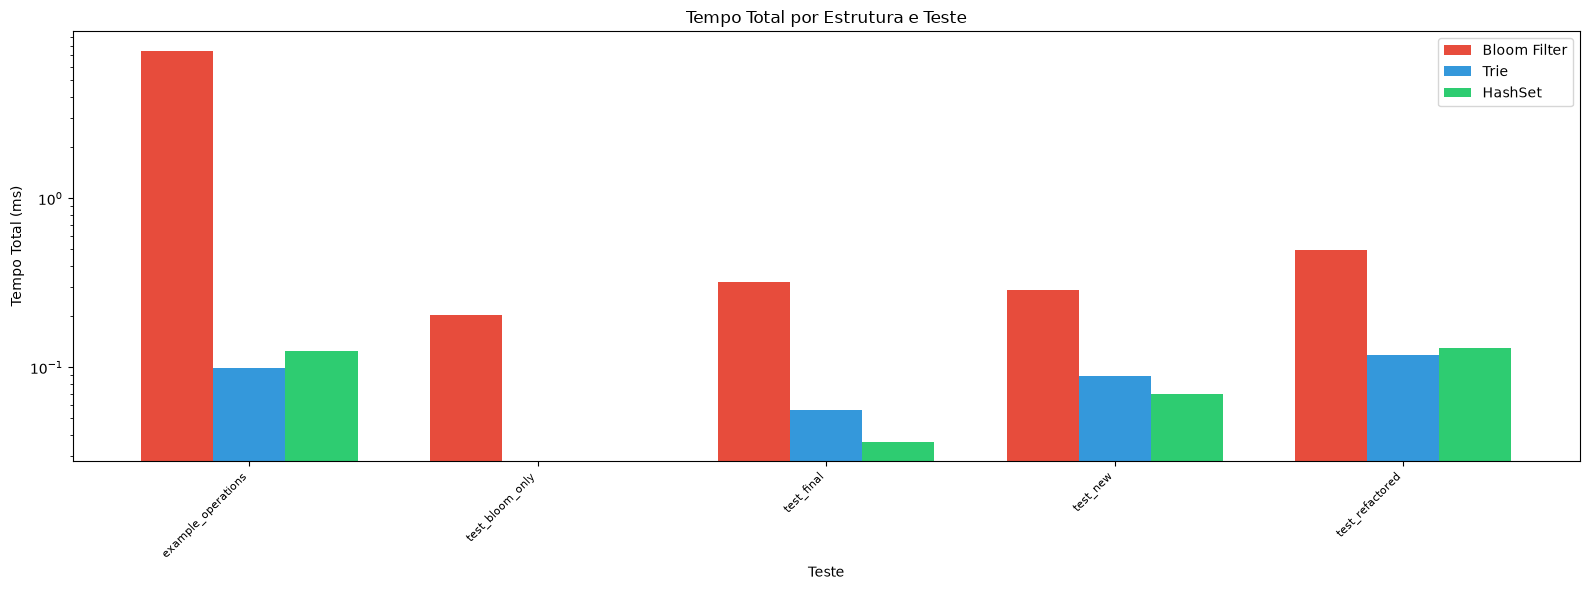

In [4]:
# Gráfico: Tempo total (ms) por estrutura, agrupado por teste
fig, ax = plt.subplots(figsize=(16, 6))
test_ids = df['test_id'].unique()
x = range(len(test_ids))
width = 0.25

for i, struct in enumerate(STRUCTURES):
    values = []
    for tid in test_ids:
        row = df[(df['test_id'] == tid) & (df['structure'] == struct)]
        values.append(row['total_time_ms'].values[0] if len(row) > 0 else 0)
    ax.bar([xi + i * width for xi in x], values, width, label=STRUCTURE_LABELS[struct], color=COLORS[struct])

ax.set_xlabel('Teste')
ax.set_ylabel('Tempo Total (ms)')
ax.set_title('Tempo Total por Estrutura e Teste')
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(test_ids, rotation=45, ha='right', fontsize=8)
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(GRAPHS_DIR / 'bar_total_time.png', dpi=150)
plt.show()

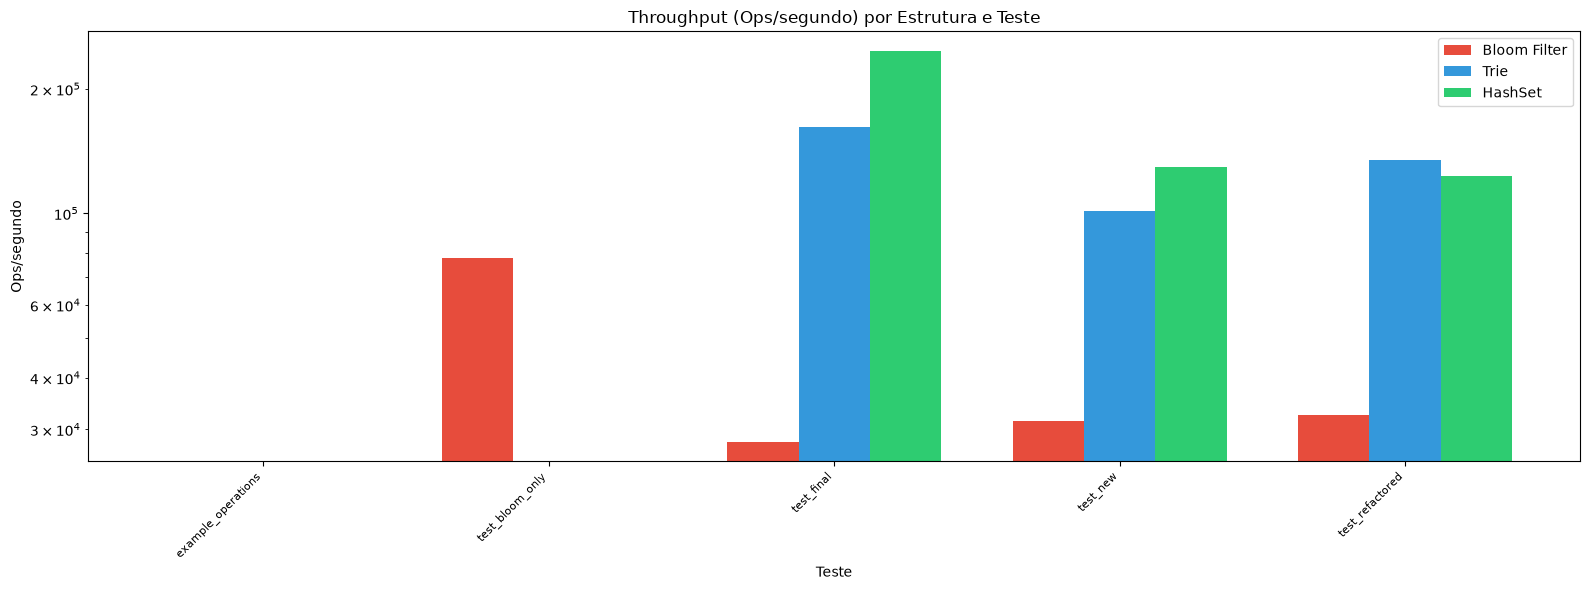

In [5]:
# Gráfico: Ops/segundo por estrutura, agrupado por teste
fig, ax = plt.subplots(figsize=(16, 6))

for i, struct in enumerate(STRUCTURES):
    values = []
    for tid in test_ids:
        row = df[(df['test_id'] == tid) & (df['structure'] == struct)]
        values.append(row['ops_per_second'].values[0] if len(row) > 0 else 0)
    ax.bar([xi + i * width for xi in x], values, width, label=STRUCTURE_LABELS[struct], color=COLORS[struct])

ax.set_xlabel('Teste')
ax.set_ylabel('Ops/segundo')
ax.set_title('Throughput (Ops/segundo) por Estrutura e Teste')
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(test_ids, rotation=45, ha='right', fontsize=8)
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(GRAPHS_DIR / 'bar_ops_per_second.png', dpi=150)
plt.show()

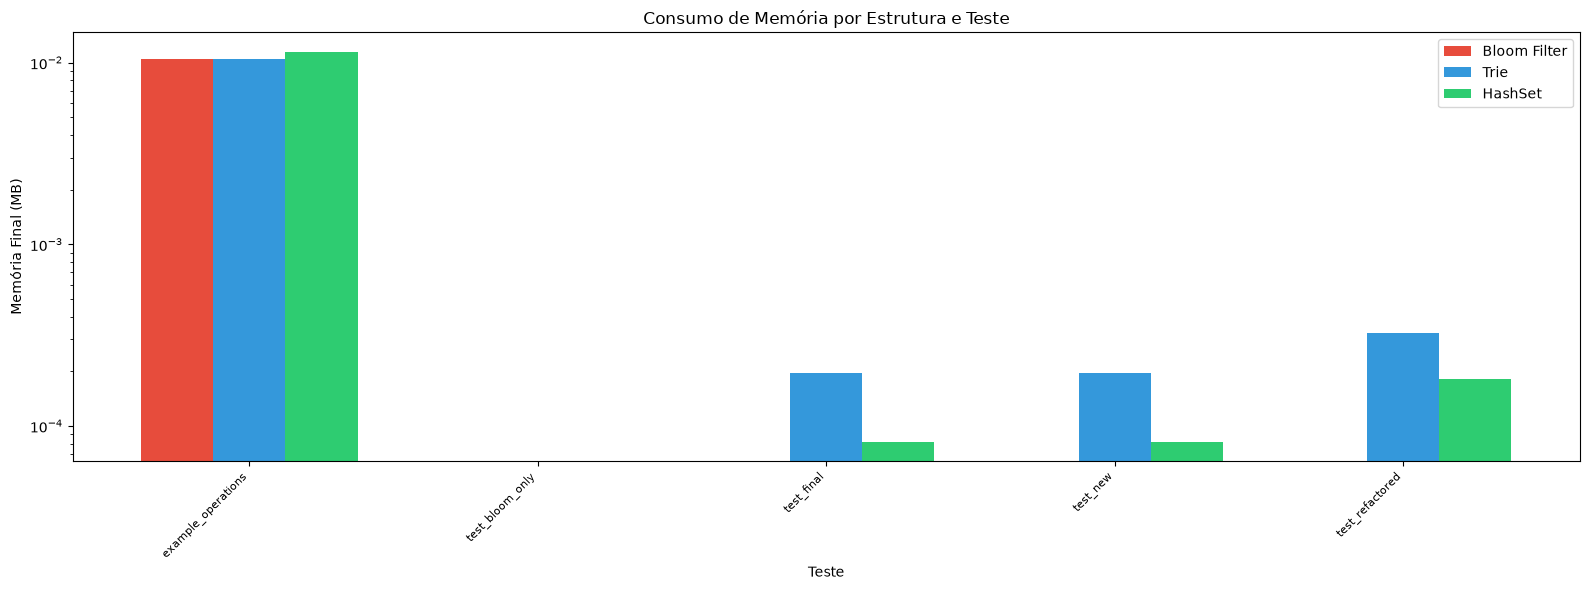

In [6]:
# Gráfico: Memória final (MB) por estrutura, agrupado por teste
fig, ax = plt.subplots(figsize=(16, 6))

for i, struct in enumerate(STRUCTURES):
    values = []
    for tid in test_ids:
        row = df[(df['test_id'] == tid) & (df['structure'] == struct)]
        values.append(row['final_memory_mb'].values[0] if len(row) > 0 else 0)
    ax.bar([xi + i * width for xi in x], values, width, label=STRUCTURE_LABELS[struct], color=COLORS[struct])

ax.set_xlabel('Teste')
ax.set_ylabel('Memória Final (MB)')
ax.set_title('Consumo de Memória por Estrutura e Teste')
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(test_ids, rotation=45, ha='right', fontsize=8)
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(GRAPHS_DIR / 'bar_final_memory.png', dpi=150)
plt.show()

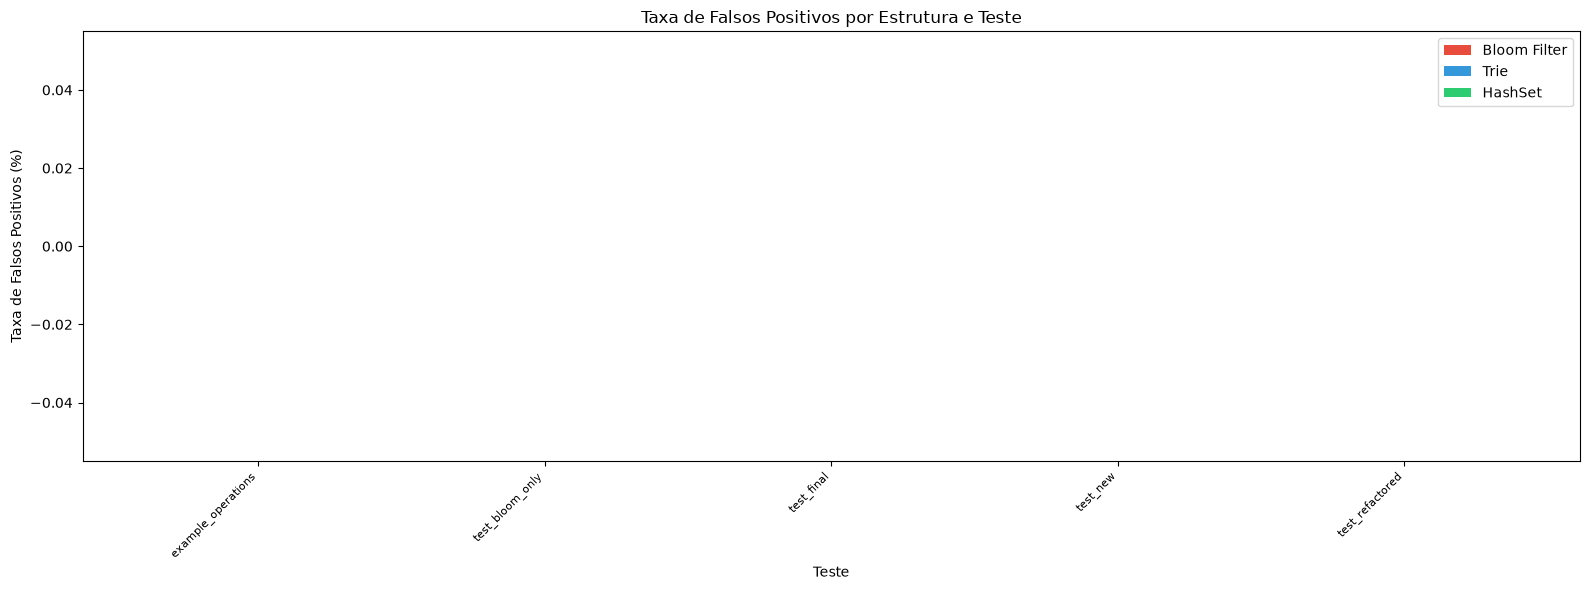

In [7]:
# Gráfico: Taxa de falsos positivos por estrutura, agrupado por teste
fig, ax = plt.subplots(figsize=(16, 6))

for i, struct in enumerate(STRUCTURES):
    values = []
    for tid in test_ids:
        row = df[(df['test_id'] == tid) & (df['structure'] == struct)]
        values.append(row['false_positive_rate'].values[0] * 100 if len(row) > 0 else 0)
    ax.bar([xi + i * width for xi in x], values, width, label=STRUCTURE_LABELS[struct], color=COLORS[struct])

ax.set_xlabel('Teste')
ax.set_ylabel('Taxa de Falsos Positivos (%)')
ax.set_title('Taxa de Falsos Positivos por Estrutura e Teste')
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(test_ids, rotation=45, ha='right', fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig(GRAPHS_DIR / 'bar_false_positive_rate.png', dpi=150)
plt.show()

## Gráficos de Evolução

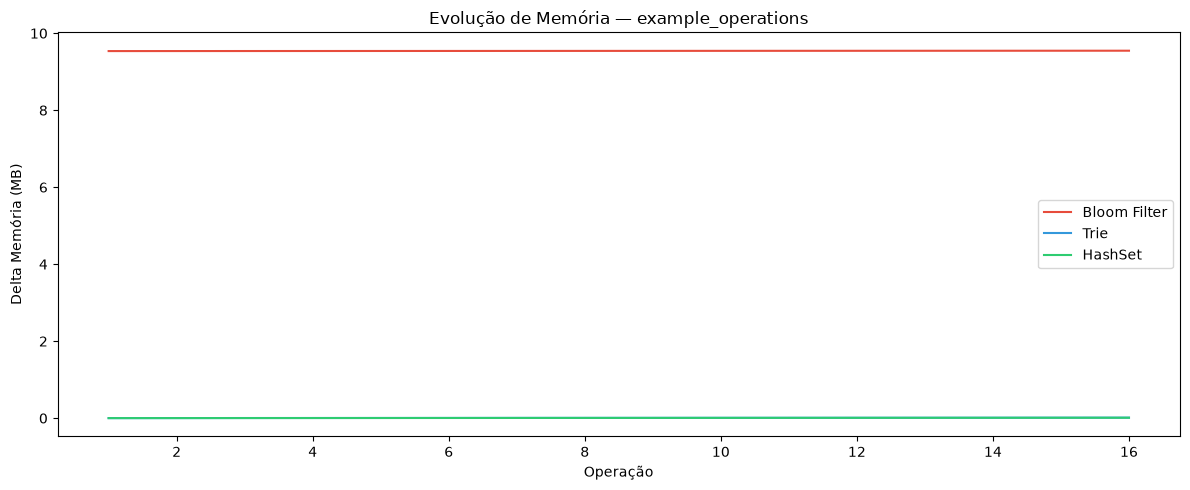

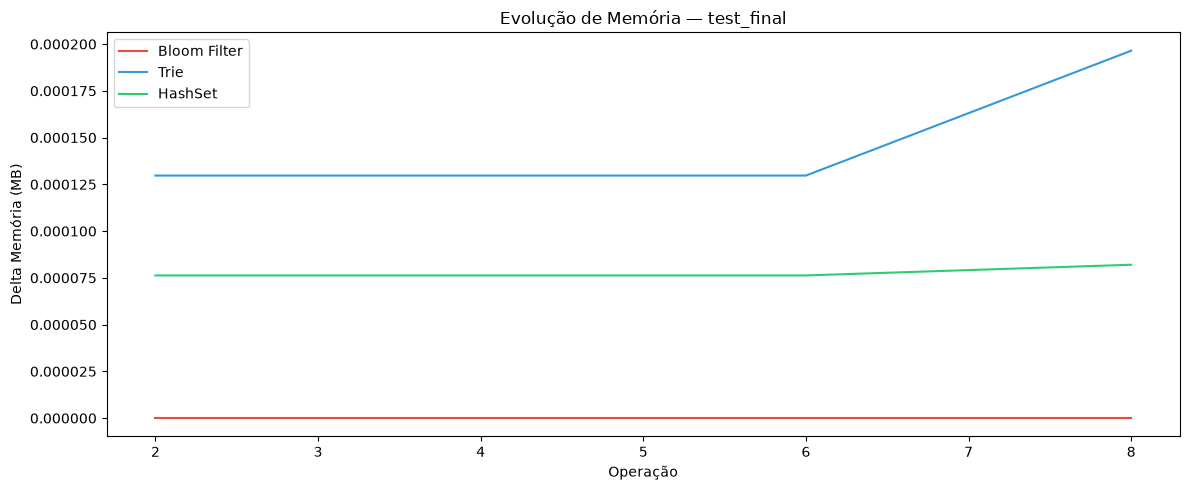

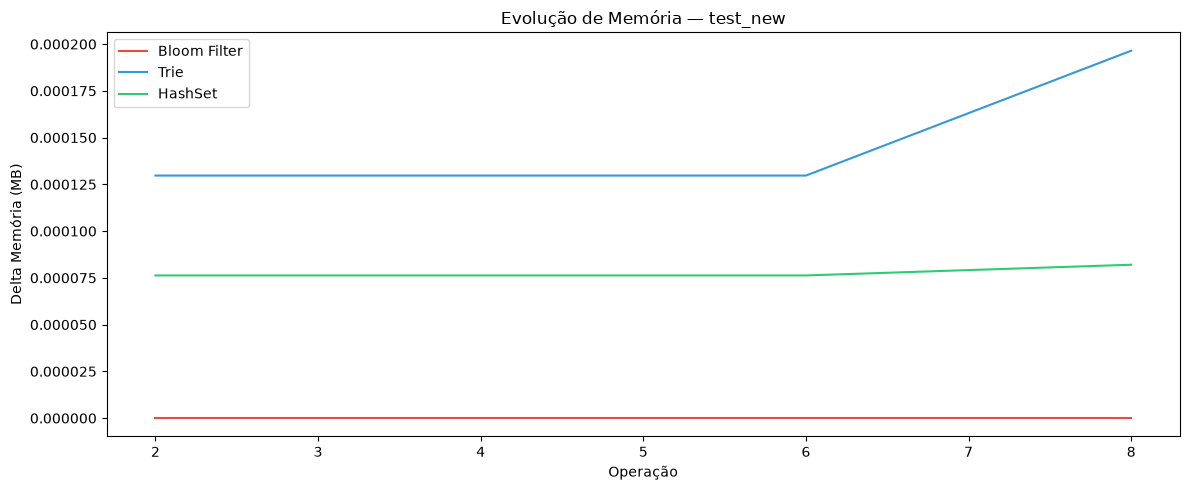

In [8]:
# Evolução de memória: um gráfico por teste, uma linha por estrutura
mem_evo = df_evo[df_evo['delta_memory_mb'].notna()].copy()

for tid in mem_evo['test_id'].unique():
    fig, ax = plt.subplots(figsize=(12, 5))
    for struct in STRUCTURES:
        sub = mem_evo[(mem_evo['test_id'] == tid) & (mem_evo['structure'] == struct)]
        if len(sub) > 0:
            ax.plot(sub['operation'], sub['delta_memory_mb'], label=STRUCTURE_LABELS[struct], color=COLORS[struct])
    ax.set_xlabel('Operação')
    ax.set_ylabel('Delta Memória (MB)')
    ax.set_title(f'Evolução de Memória — {tid}')
    ax.legend()
    plt.tight_layout()
    plt.savefig(GRAPHS_DIR / f'line_memory_evolution_{tid}.png', dpi=150)
    plt.show()

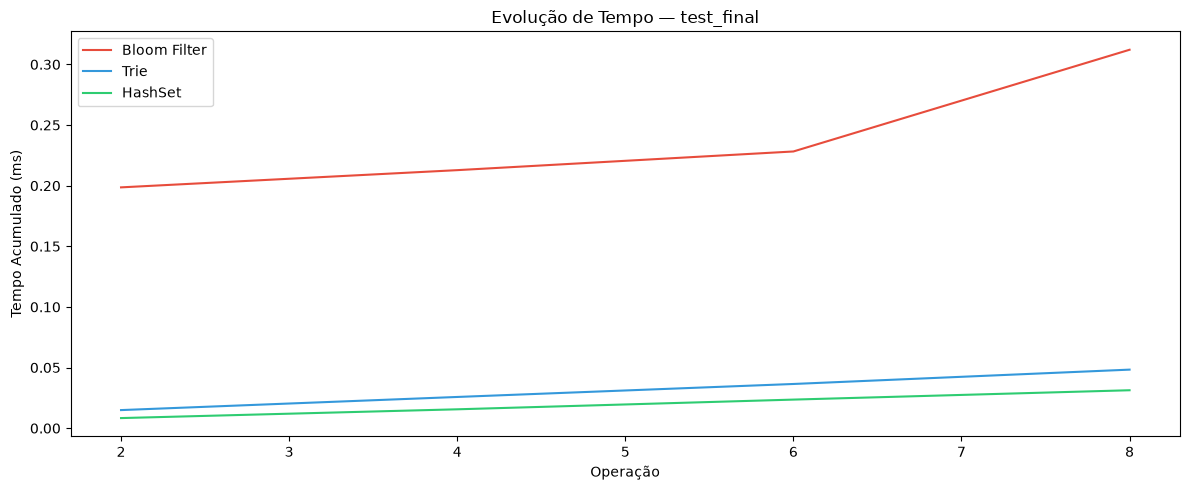

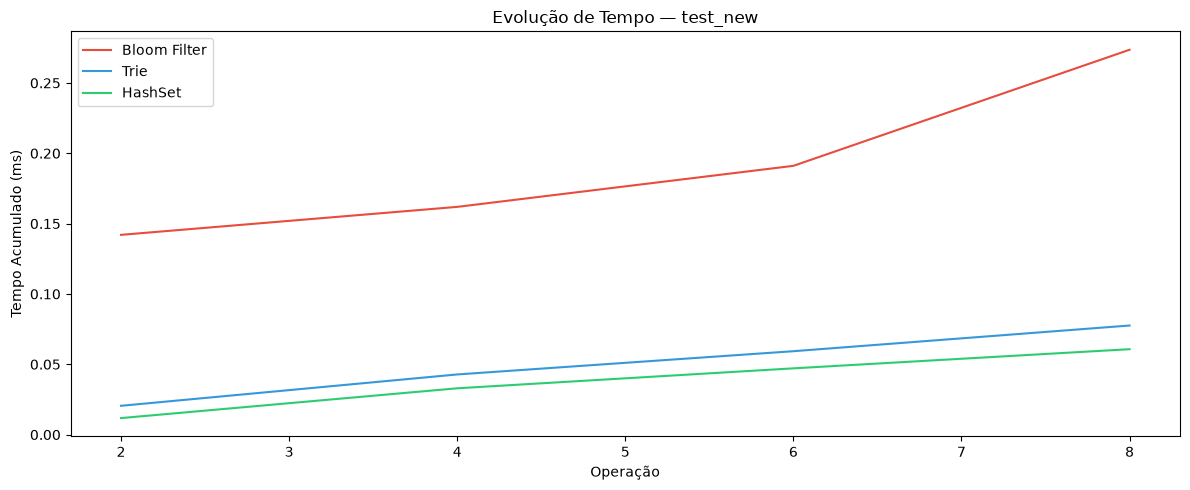

In [9]:
# Evolução de tempo: um gráfico por teste, uma linha por estrutura
time_evo = df_evo[df_evo['elapsed_ms'].notna()].copy()

for tid in time_evo['test_id'].unique():
    fig, ax = plt.subplots(figsize=(12, 5))
    for struct in STRUCTURES:
        sub = time_evo[(time_evo['test_id'] == tid) & (time_evo['structure'] == struct)]
        if len(sub) > 0:
            ax.plot(sub['operation'], sub['elapsed_ms'], label=STRUCTURE_LABELS[struct], color=COLORS[struct])
    ax.set_xlabel('Operação')
    ax.set_ylabel('Tempo Acumulado (ms)')
    ax.set_title(f'Evolução de Tempo — {tid}')
    ax.legend()
    plt.tight_layout()
    plt.savefig(GRAPHS_DIR / f'line_time_evolution_{tid}.png', dpi=150)
    plt.show()

## Tabela Resumo

In [10]:
# Tabela pivô: linhas = testes, colunas = estruturas, valores = ops/segundo
pivot = df.pivot_table(index='test_id', columns='structure', values='ops_per_second')
pivot = pivot.reindex(columns=STRUCTURES)
pivot.columns = [STRUCTURE_LABELS[c] for c in pivot.columns]
pivot = pivot.round(0)
pivot

,Bloom Filter,Trie,HashSet
test_id,,,
example_operations,0.0,0.0,0.0
test_bloom_only,78188.0,NaN,NaN
test_final,28027.0,161652.0,247395.0
test_new,31371.0,101308.0,129179.0
test_refactored,32543.0,134348.0,123214.0


In [11]:
# Tabela pivô: memória final (MB)
pivot_mem = df.pivot_table(index='test_id', columns='structure', values='final_memory_mb')
pivot_mem = pivot_mem.reindex(columns=STRUCTURES)
pivot_mem.columns = [STRUCTURE_LABELS[c] for c in pivot_mem.columns]
pivot_mem = pivot_mem.round(4)
pivot_mem

,Bloom Filter,Trie,HashSet
test_id,,,
example_operations,0.0105,0.0105,0.0115
test_bloom_only,0.0000,NaN,NaN
test_final,0.0000,0.0002,0.0001
test_new,0.0000,0.0002,0.0001
test_refactored,0.0000,0.0003,0.0002


In [12]:
# Exportar tabelas para CSV
pivot.to_csv(GRAPHS_DIR / 'summary_ops_per_second.csv')
pivot_mem.to_csv(GRAPHS_DIR / 'summary_memory_mb.csv')
df.to_csv(GRAPHS_DIR / 'full_results.csv', index=False)
print(f'Tabelas e gráficos salvos em: {GRAPHS_DIR}')
print(f'Arquivos gerados: {len(list(GRAPHS_DIR.glob("*.png")))} gráficos, {len(list(GRAPHS_DIR.glob("*.csv")))} CSVs')

Tabelas e gráficos salvos em: /home/joaogabriels/j1/ufcg/leda/projeto-final/data/graphs
Arquivos gerados: 9 gráficos, 3 CSVs
